## Practice Lab Lecture 13 - Decision Trees
In this lab we will use decision trees classification for the IRIS dataset. 
Based on Chapter 6 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice13DT.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


### Exercise 1: 
Let us take the Iris data set as before. Let us apply the classification using Gini and Entropy and compare results using Depth = 2.\
Then compare with Depth = 3 (for either of the criterion). Compare these last two and explain which works better for this case and why.


In [52]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target

tree_clf1 = DecisionTreeClassifier(max_depth=2, random_state=42, criterion='entropy')
tree_clf2 = DecisionTreeClassifier(max_depth=2, random_state=42, criterion='gini')
tree_clf3 = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini')
print(tree_clf1.fit(X, y))
print(tree_clf2.fit(X, y))
print(tree_clf3.fit(X, y))

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=2,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=42, splitter='best')
DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=2,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=42, splitter='best')
DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=3,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurit

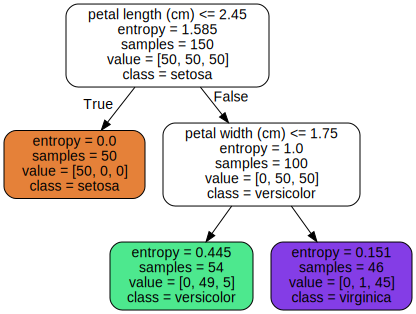

In [53]:
from graphviz import Source
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf1,
        out_file="iris_treeEntropy.dot",
        feature_names=iris.feature_names[2:],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

Source.from_file("iris_treeEntropy.dot")

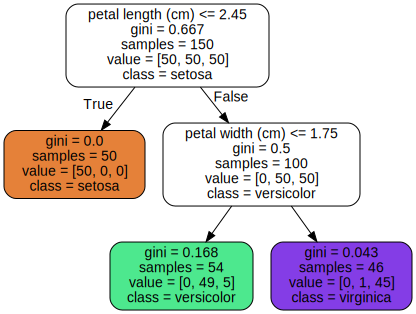

In [54]:
from graphviz import Source
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf2,
        out_file="iris_treeGini.dot",
        feature_names=iris.feature_names[2:],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

Source.from_file("iris_treeGini.dot")

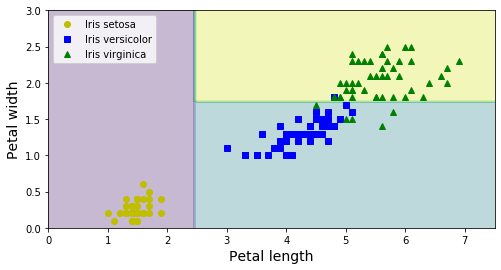

In [55]:
# To plot decision boundaries we can use the same idea as in previous Lectures.
# Create a grid with meshgrid containing the two features and the predict their output for each.
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
    plt.axis(axes)
    plt.legend()


plt.figure(figsize=(8, 4))
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plot_decision_boundary(tree_clf2, X, y)


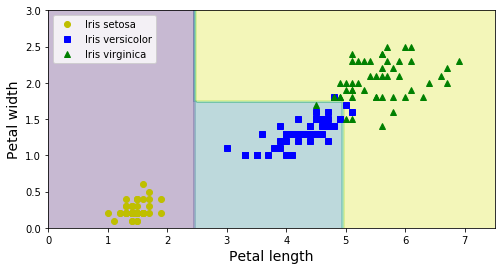

In [57]:
plt.figure(figsize=(8, 4))
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plot_decision_boundary(tree_clf3, X, y)

## Exercise 2
Use the make_moons class from sklearn with 100 samples and create two trees, one with no restrictions and the other with different restrictions

In [5]:
# Example without restrictions
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=53)
deep_tree_clf1 = DecisionTreeClassifier(random_state=42)
deep_tree_clf1.fit(Xm, ym)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=42, splitter='best')

Text(0.5, 1.0, 'No restrictions')

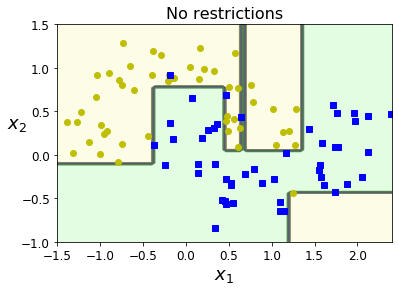

In [6]:
plot_decision_boundary(deep_tree_clf1, Xm, ym, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("No restrictions", fontsize=16)

Now, try different parameters to restrict the tree and plot again. For example, in the book min_samples_leaf=4 is used. You can try other parameters and see how the tree changes. 

In [7]:
deep_tree_clf2 = DecisionTreeClassifier(min_impurity_decrease=0.004, random_state=42)
deep_tree_clf2.fit(Xm, ym)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.004, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=42, splitter='best')

Text(0.5, 1.0, 'min_samples_leaf = 1')

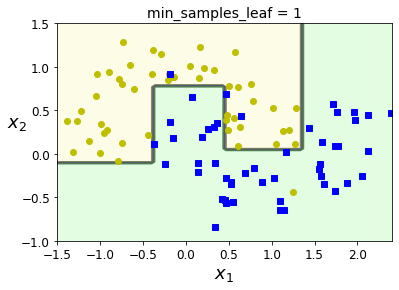

In [8]:

plot_decision_boundary(deep_tree_clf2, Xm, ym, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("min_samples_leaf = {}".format(deep_tree_clf2.min_samples_leaf), fontsize=14)

## Exercise 3:
Define a polynomial of third degree, add noise, and try to fit a tree of any depth you wish. Then apply regularization.

In [9]:
# Quadratic training set + noise
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5) ** 2 + 10 * (X-0.4) **3
y = y + np.random.randn(m, 1) / 10

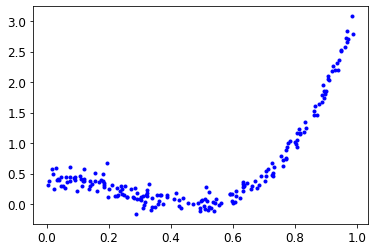

In [10]:
plt.plot(X,y,'b.')

In [11]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=9, random_state=42, min_samples_leaf=10)
tree_reg.fit(X, y)

DecisionTreeRegressor(criterion='mse', max_depth=9, max_features=None,
                      max_leaf_nodes=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=10,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      presort=False, random_state=42, splitter='best')

In [12]:
def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -0.2, 1], ylabel="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    if ylabel:
        plt.ylabel(ylabel, fontsize=18, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

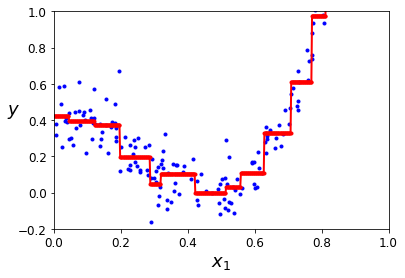

In [13]:
plot_regression_predictions(tree_reg, X, y)